# Notebook 03 — Análisis Exploratorio y Validación de Hipótesis

## FitLife Analytics

Este notebook retoma el dataset enriquecido generado en el Notebook 02 y valida, una por una, las hipótesis planteadas en el `business_case.md`.

**Continuidad del proyecto:** los Notebooks 01 y 02 ya identificaron que `Avg_additional_charges_total`, `Avg_class_frequency_total` y `Avg_class_frequency_current_month` están afectadas por un bug de exportación irreversible y se excluyeron del dataset. Por eso la **Hipótesis H2** (caída de frecuencia de visitas) no se puede verificar y no aparece en este notebook (ver `business_case.md`, apartado 2.1).

---
## 1. Carga de librerías y datos

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style='whitegrid', palette='muted')

print('Librerías cargadas correctamente')

Librerías cargadas correctamente


In [2]:
df = pd.read_csv('../data/processed/gym_churn_enriquecido.csv')

print(f'Filas:    {df.shape[0]}')
print(f'Columnas: {df.shape[1]}')
df.head(3)

Filas:    4000
Columnas: 17


,gender,Near_Location,Partner,Promo_friends,Phone,Contract_period,Group_visits,Age,Month_to_end_contract,Lifetime,Churn,genero_texto,grupo_edad,tipo_contrato,nivel_compromiso,perfil_captacion,segmento_lifetime
0,1,1,1,1,0,6,1,29,5.0,3,0,Hombre,26-30,semestral,medio,referido_sin_contacto,nuevo
1,0,1,0,0,1,12,1,31,12.0,7,0,Mujer,31-35,anual,alto,organico_contactado,intermedio
2,0,1,1,0,1,1,0,28,1.0,2,0,Mujer,26-30,mensual,bajo,organico_contactado,nuevo


### Tasa de abandono global

Referencia para comparar el resto de hipótesis: si un grupo está por encima de esta línea, abandona más que la media; si está por debajo, retiene mejor que la media.

In [3]:
tasa_global = df['Churn'].mean() * 100
print(f'Tasa de abandono global: {tasa_global:.2f}%')

Tasa de abandono global: 26.52%


---
## 2. Hipótesis H1 — Tipo de contrato

> Los socios con contrato mensual tienen una tasa de abandono muy superior a los de contrato semestral o anual.

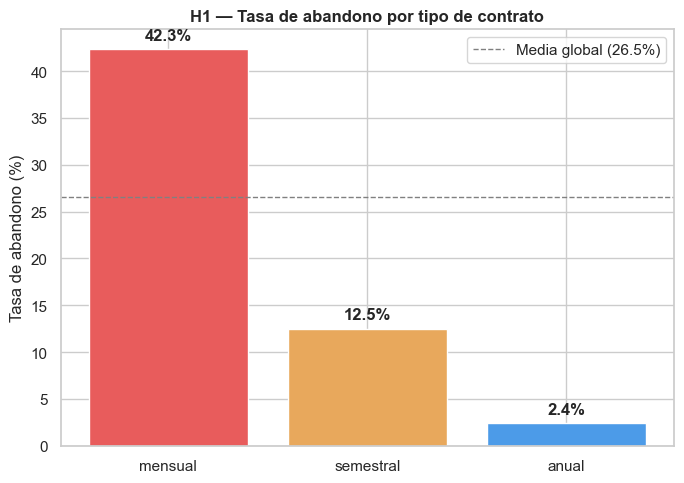

In [4]:
ORDEN_CONTRATO = ['mensual', 'semestral', 'anual']
tasas_contrato = df.groupby('tipo_contrato')['Churn'].mean().reindex(ORDEN_CONTRATO) * 100

fig, ax = plt.subplots(figsize=(7, 5))
colores = ['#E85C5C', '#E8A85C', '#4C9BE8']
barras = ax.bar(ORDEN_CONTRATO, tasas_contrato, color=colores)

ax.axhline(tasa_global, color='gray', linestyle='--', linewidth=1, label=f'Media global ({tasa_global:.1f}%)')
ax.set_ylabel('Tasa de abandono (%)')
ax.set_title('H1 — Tasa de abandono por tipo de contrato', fontweight='bold')
ax.legend()

for barra, valor in zip(barras, tasas_contrato):
    ax.text(barra.get_x() + barra.get_width()/2, valor + 1, f'{valor:.1f}%', ha='center', fontweight='bold')

plt.tight_layout()
plt.savefig('../docs/img/12_h1_contrato.png', bbox_inches='tight')
plt.show()

**Conclusión H1: confirmada.** Los socios con contrato mensual abandonan en el 42.3% de los casos, frente al 12.5% de los semestrales y solo el 2.4% de los anuales — una diferencia de más de 17 veces entre el extremo más alto y el más bajo. Cuanto mayor es el compromiso contractual, menor es el abandono.

---
## 3. Hipótesis H3 — Canal de captación

> Los socios captados por recomendación de amigos tienen menor tasa de abandono que los captados por otros canales.

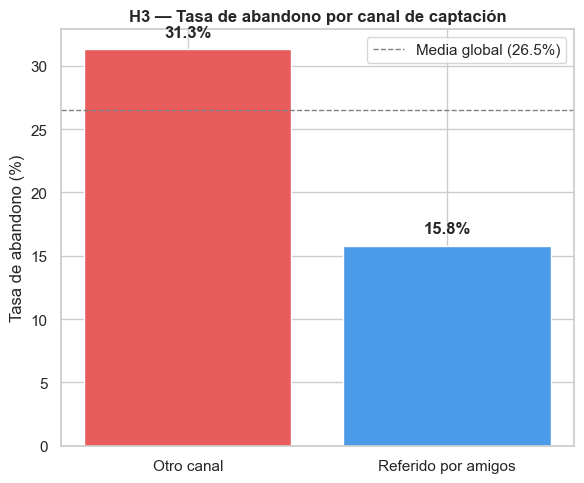

In [5]:
ETIQUETAS_PROMO = {0: 'Otro canal', 1: 'Referido por amigos'}
tasas_promo = df.groupby('Promo_friends')['Churn'].mean() * 100
tasas_promo.index = tasas_promo.index.map(ETIQUETAS_PROMO)

fig, ax = plt.subplots(figsize=(6, 5))
barras = ax.bar(tasas_promo.index, tasas_promo.values, color=['#E85C5C', '#4C9BE8'])

ax.axhline(tasa_global, color='gray', linestyle='--', linewidth=1, label=f'Media global ({tasa_global:.1f}%)')
ax.set_ylabel('Tasa de abandono (%)')
ax.set_title('H3 — Tasa de abandono por canal de captación', fontweight='bold')
ax.legend()

for barra, valor in zip(barras, tasas_promo.values):
    ax.text(barra.get_x() + barra.get_width()/2, valor + 1, f'{valor:.1f}%', ha='center', fontweight='bold')

plt.tight_layout()
plt.savefig('../docs/img/13_h3_captacion.png', bbox_inches='tight')
plt.show()

**Conclusión H3: confirmada.** Los socios referidos por amigos abandonan en el 15.8% de los casos, frente al 31.3% del resto de canales — prácticamente la mitad. Tiene sentido de negocio: quien llega recomendado por un conocido suele venir con expectativas más realistas y, a menudo, entrena acompañado, lo que refuerza el hábito.

---
## 4. Hipótesis H4 — Clases grupales

> Los socios que asisten a clases grupales tienen menor probabilidad de abandono que los que solo usan la sala libre.

**Nota de alcance:** esta hipótesis se planteó originalmente cruzando clases grupales con la tendencia de frecuencia de visitas. Esa segunda variable ya no está disponible (bug de datos), así que aquí se verifica solo con `Group_visits`.

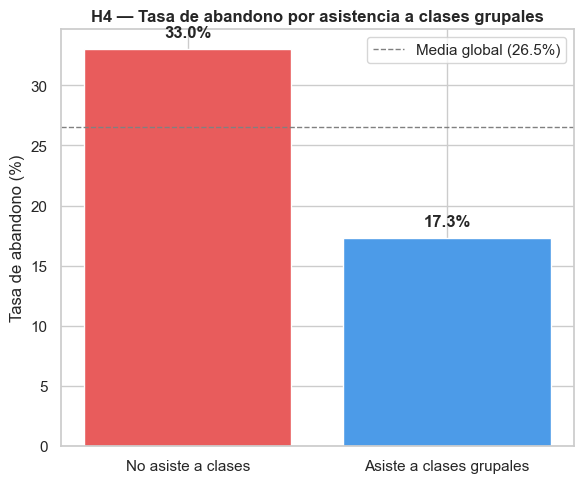

In [6]:
ETIQUETAS_CLASES = {0: 'No asiste a clases', 1: 'Asiste a clases grupales'}
tasas_clases = df.groupby('Group_visits')['Churn'].mean() * 100
tasas_clases.index = tasas_clases.index.map(ETIQUETAS_CLASES)

fig, ax = plt.subplots(figsize=(6, 5))
barras = ax.bar(tasas_clases.index, tasas_clases.values, color=['#E85C5C', '#4C9BE8'])

ax.axhline(tasa_global, color='gray', linestyle='--', linewidth=1, label=f'Media global ({tasa_global:.1f}%)')
ax.set_ylabel('Tasa de abandono (%)')
ax.set_title('H4 — Tasa de abandono por asistencia a clases grupales', fontweight='bold')
ax.legend()

for barra, valor in zip(barras, tasas_clases.values):
    ax.text(barra.get_x() + barra.get_width()/2, valor + 1, f'{valor:.1f}%', ha='center', fontweight='bold')

plt.tight_layout()
plt.savefig('../docs/img/14_h4_clases.png', bbox_inches='tight')
plt.show()

In [7]:
# Cruce adicional: clases grupales x antigüedad (ya visto en SQL, Query 3)
# Confirma que el efecto de las clases se mantiene incluso entre los socios más vulnerables (nuevos)
tabla_cruce = df.groupby(['segmento_lifetime', 'Group_visits'])['Churn'].mean().mul(100).round(2)
tabla_cruce = tabla_cruce.reindex(['nuevo', 'intermedio', 'veterano'], level=0)
tabla_cruce

segmento_lifetime  Group_visits
nuevo              0               49.67
                   1               29.96
intermedio         0                3.87
                   1                1.07
veterano           0                0.00
                   1                0.00
Name: Churn, dtype: float64

**Conclusión H4: confirmada.** Los socios que asisten a clases grupales abandonan en el 17.3% de los casos, frente al 33.0% de quienes no asisten — prácticamente la mitad. El efecto se mantiene incluso entre los socios nuevos (el segmento de mayor riesgo): 29.96% de abandono con clases frente a 49.67% sin ellas.

---
## 5. Hipótesis H5 — Pareja socia

> Los socios cuya pareja también está inscrita presentan mayor retención.

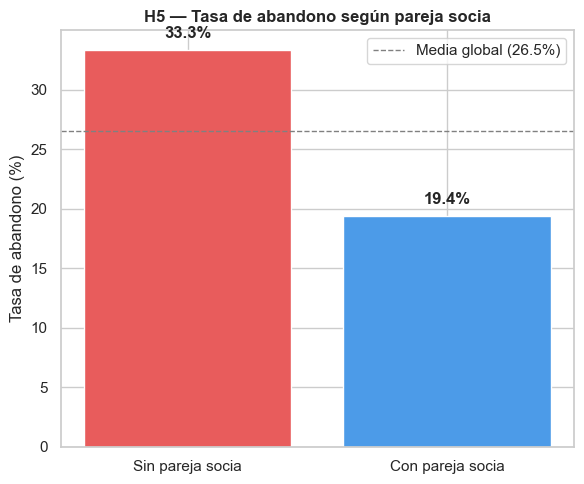

In [8]:
ETIQUETAS_PARTNER = {0: 'Sin pareja socia', 1: 'Con pareja socia'}
tasas_partner = df.groupby('Partner')['Churn'].mean() * 100
tasas_partner.index = tasas_partner.index.map(ETIQUETAS_PARTNER)

fig, ax = plt.subplots(figsize=(6, 5))
barras = ax.bar(tasas_partner.index, tasas_partner.values, color=['#E85C5C', '#4C9BE8'])

ax.axhline(tasa_global, color='gray', linestyle='--', linewidth=1, label=f'Media global ({tasa_global:.1f}%)')
ax.set_ylabel('Tasa de abandono (%)')
ax.set_title('H5 — Tasa de abandono según pareja socia', fontweight='bold')
ax.legend()

for barra, valor in zip(barras, tasas_partner.values):
    ax.text(barra.get_x() + barra.get_width()/2, valor + 1, f'{valor:.1f}%', ha='center', fontweight='bold')

plt.tight_layout()
plt.savefig('../docs/img/15_h5_pareja.png', bbox_inches='tight')
plt.show()

**Conclusión H5: confirmada.** Los socios con pareja también inscrita abandonan en el 19.4% de los casos, frente al 33.3% de quienes no la tienen. Entrenar acompañado parece actuar como un factor de retención social, similar al efecto de las clases grupales.

---
## 6. Hipótesis H6 — Antigüedad

> Los socios más nuevos (menos de 6 meses de antigüedad) tienen mayor riesgo de abandono que los veteranos.

**Nota:** el `business_case.md` planteaba el corte en 6 meses; el campo `segmento_lifetime` creado en el Notebook 02 usa un corte en 3 meses (período más crítico según la correlación Lifetime-Churn). Se mantiene el segmento ya construido por coherencia con el resto del proyecto.

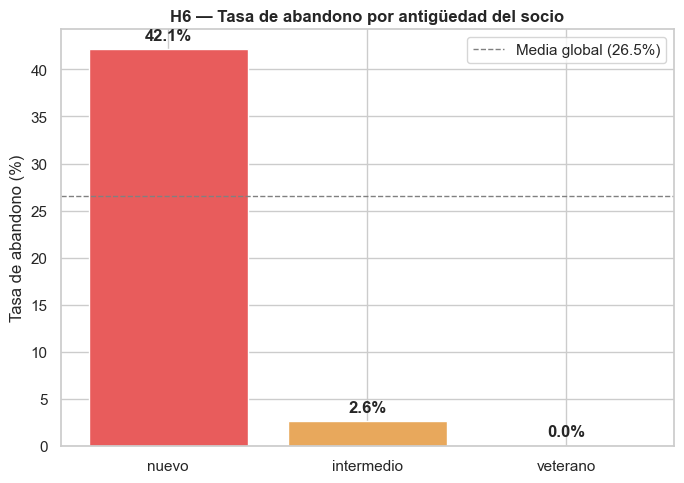

In [9]:
ORDEN_LIFETIME = ['nuevo', 'intermedio', 'veterano']
tasas_lifetime = df.groupby('segmento_lifetime')['Churn'].mean().reindex(ORDEN_LIFETIME) * 100

fig, ax = plt.subplots(figsize=(7, 5))
colores = ['#E85C5C', '#E8A85C', '#4C9BE8']
barras = ax.bar(ORDEN_LIFETIME, tasas_lifetime, color=colores)

ax.axhline(tasa_global, color='gray', linestyle='--', linewidth=1, label=f'Media global ({tasa_global:.1f}%)')
ax.set_ylabel('Tasa de abandono (%)')
ax.set_title('H6 — Tasa de abandono por antigüedad del socio', fontweight='bold')
ax.legend()

for barra, valor in zip(barras, tasas_lifetime):
    ax.text(barra.get_x() + barra.get_width()/2, valor + 1, f'{valor:.1f}%', ha='center', fontweight='bold')

plt.tight_layout()
plt.savefig('../docs/img/16_h6_antiguedad.png', bbox_inches='tight')
plt.show()

**Conclusión H6: confirmada, y con más intensidad de la esperada.** Los socios nuevos (0-3 meses) abandonan en el 42.1% de los casos, frente al 2.6% de los intermedios y un 0.0% entre los veteranos (más de 12 meses). La práctica totalidad del abandono de FitLife ocurre en los primeros meses de vida del socio.

---
## 7. Hallazgo adicional — Edad

No estaba entre las hipótesis formales del `business_case.md`, pero responde directamente a una de las preguntas de negocio planteadas: *¿qué perfil de socio abandona más?*

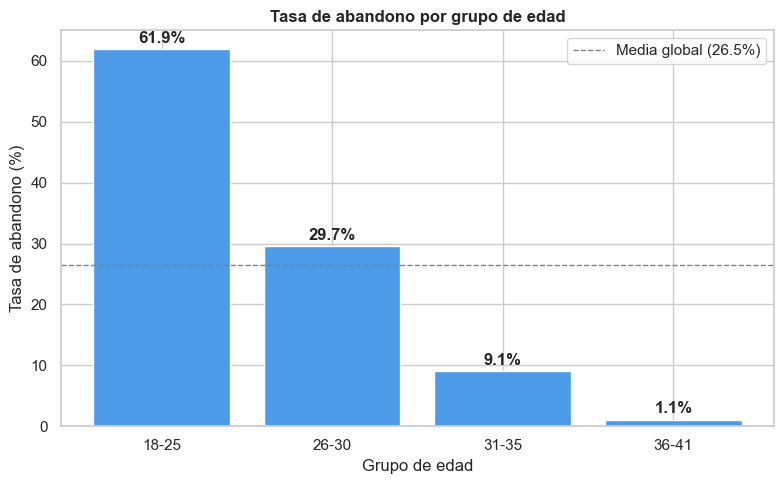

In [10]:
ORDEN_EDAD = ['18-25', '26-30', '31-35', '36-41']
tasas_edad = df.groupby('grupo_edad')['Churn'].mean().reindex(ORDEN_EDAD) * 100

fig, ax = plt.subplots(figsize=(8, 5))
barras = ax.bar(ORDEN_EDAD, tasas_edad, color='#4C9BE8')

ax.axhline(tasa_global, color='gray', linestyle='--', linewidth=1, label=f'Media global ({tasa_global:.1f}%)')
ax.set_ylabel('Tasa de abandono (%)')
ax.set_xlabel('Grupo de edad')
ax.set_title('Tasa de abandono por grupo de edad', fontweight='bold')
ax.legend()

for barra, valor in zip(barras, tasas_edad):
    ax.text(barra.get_x() + barra.get_width()/2, valor + 1, f'{valor:.1f}%', ha='center', fontweight='bold')

plt.tight_layout()
plt.savefig('../docs/img/17_edad.png', bbox_inches='tight')
plt.show()

**Hallazgo: tendencia muy marcada con la edad.** El abandono cae de forma casi lineal a medida que aumenta la edad: 61.9% en el grupo 18-25, hasta apenas el 1.1% en 36-41. Los socios más jóvenes son, con diferencia, el segmento de mayor riesgo — probablemente asociado a su menor estabilidad de rutinas y mayor sensibilidad al precio.

---
## 8. Resumen de hipótesis y conclusiones del Notebook 03

| Hipótesis | Resultado | Hallazgo principal |
|---|---|---|
| H1 — Tipo de contrato | ✅ Confirmada | Mensual: 42.3% / Semestral: 12.5% / Anual: 2.4% |
| H2 — Caída de frecuencia | ⛔ No verificable | Excluida por bug de datos (ver business_case.md, 2.1) |
| H3 — Canal de captación | ✅ Confirmada | Referidos: 15.8% / Resto: 31.3% |
| H4 — Clases grupales | ✅ Confirmada | Con clases: 17.3% / Sin clases: 33.0% |
| H5 — Pareja socia | ✅ Confirmada | Con pareja: 19.4% / Sin pareja: 33.3% |
| H6 — Antigüedad | ✅ Confirmada | Nuevo: 42.1% / Intermedio: 2.6% / Veterano: 0.0% |

**Hallazgo adicional:** la edad muestra una relación muy fuerte con el abandono (61.9% en 18-25 años frente a 1.1% en 36-41 años), pendiente de incorporar como variable predictora en el modelo de la Fase 6.

### Perfil de socio de mayor riesgo (síntesis)
Socio **nuevo** (menos de 3 meses), con contrato **mensual**, **joven** (18-25 años), que **no asiste a clases grupales**, **sin pareja socia** y captado por un canal **distinto a la recomendación de amigos**. Este perfil combina los seis factores que más elevan el riesgo de abandono según el análisis anterior.

### Próximos pasos
Estas mismas variables (`tipo_contrato`, `Group_visits`, `Partner`, `Promo_friends`, `segmento_lifetime`, `Age`) son las que alimentarán el modelo de Regresión Logística de la Fase 6.